# VOIS Major Project - Seasonal Agriculture Performance Analysis

**Dataset:** Seasonal Agriculture Performance Dataset  
**Records:** 4,000 farm observations | **Original variables:** 28

## Problem Statement
Agricultural activities vary with seasonal environmental conditions, farming practices, resource availability and market conditions. The supplied dataset contains farm-level information across seasons, crops, regions, environmental factors, resource use and financial outcomes. The project investigates seasonal differences in agricultural performance and converts the results into evidence-based insights.

## Objectives
- Explore and understand the dataset.
- Clean and prepare the data.
- Compare Kharif, Rabi and Zaid.
- Analyze environmental, agronomic, resource and financial indicators.
- Compare crops, regions and irrigation methods.
- Quantify relationships using correlation.
- Test seasonal yield differences statistically.
- Develop conclusions and recommendations.


## 1. Import libraries and load the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv("C:\\Users\\Hp\\Desktop\\Advanced_Data_Sciecne-LAB\\seasonal_agriculture_performance_dataset.csv")
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 2. Data quality assessment

In [2]:
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

Duplicate rows: 0

Missing values:


,missing_count
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0



Data types:


,dtype
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


### Cleaning approach
Numeric missing values are replaced by the median to reduce sensitivity to extreme observations. Categorical missing values, if present, are replaced by the mode. A derived **Profit Margin (%)** KPI is created for economic interpretation.

In [3]:
clean=df.copy()
numeric_cols=clean.select_dtypes(include=np.number).columns.tolist()
categorical_cols=clean.select_dtypes(include="object").columns.tolist()

for col in numeric_cols:
    clean[col]=clean[col].fillna(clean[col].median())
for col in categorical_cols:
    clean[col]=clean[col].fillna(clean[col].mode()[0])

clean["Profit_Margin_pct"]=np.where(
    clean["Revenue_INR"]!=0,
    clean["Profit_INR"]/clean["Revenue_INR"]*100,
    np.nan
)

print("Remaining missing values:", int(clean.isna().sum().sum()))
print("Remaining duplicates:", int(clean.duplicated().sum()))

Remaining missing values: 0
Remaining duplicates: 0


## 3. Descriptive statistics

In [4]:
display(clean.describe(include="all").T)
for col in ["State","District","Crop","Season","Irrigation_Method"]:
    print(f"{col}: {clean[col].nunique()} unique values")

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,"4,000.00",NaN,NaN,NaN,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"4,000.00",NaN,NaN,NaN,600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20"
Avg_Temperature_C,"4,000.00",NaN,NaN,NaN,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",NaN,NaN,NaN,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",NaN,NaN,NaN,7.32,1.12,3.50,6.60,7.30,8.10,11.00


State: 8 unique values
District: 10 unique values
Crop: 8 unique values
Season: 3 unique values
Irrigation_Method: 4 unique values


## 4. Seasonal performance analysis

In [5]:
season_order=["Kharif","Rabi","Zaid"]
season_summary=clean.groupby("Season").agg(
    Farms=("Farm_ID","count"),
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha","mean"),
    Avg_Profit_INR=("Profit_INR","mean"),
    Avg_Revenue_INR=("Revenue_INR","mean"),
    Avg_Cost_INR=("Total_Cost_INR","mean"),
    Avg_Water_Used_m3=("Water_Used_m3","mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean"),
    Avg_Disease_Risk_pct=("Disease_Pest_Risk_pct","mean"),
    Avg_Rainfall_mm=("Rainfall_mm","mean"),
    Avg_Temperature_C=("Avg_Temperature_C","mean")
).reindex(season_order)
display(season_summary.round(2))

,Farms,Avg_Yield_Tonnes_Ha,Avg_Profit_INR,Avg_Revenue_INR,Avg_Cost_INR,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Risk_pct,Avg_Rainfall_mm,Avg_Temperature_C
Season,,,,,,,,,,
Kharif,1779,5.63,"178,914.65","710,719.06","531,804.41","6,102.20",5.89,54.47,849.20,28.45
Rabi,1627,5.04,"87,689.47","601,526.05","513,836.58","5,846.99",5.19,40.48,437.62,23.49
Zaid,594,4.64,"-24,804.82","519,171.90","543,976.73","6,419.89",4.41,38.22,304.65,31.04


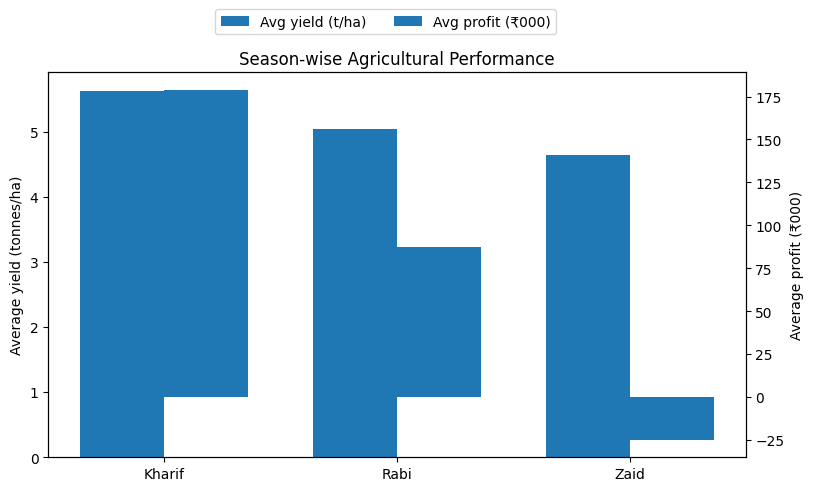

In [6]:
fig,ax1=plt.subplots(figsize=(9,5))
x=np.arange(3)
ax1.bar(x-.18,season_summary["Avg_Yield_Tonnes_Ha"],width=.36,label="Avg yield (t/ha)")
ax1.set_ylabel("Average yield (tonnes/ha)")
ax1.set_xticks(x); ax1.set_xticklabels(season_order)
ax2=ax1.twinx()
ax2.bar(x+.18,season_summary["Avg_Profit_INR"]/1000,width=.36,label="Avg profit (₹000)")
ax2.set_ylabel("Average profit (₹000)")
ax1.set_title("Season-wise Agricultural Performance")
fig.legend(loc="upper center",ncol=2,bbox_to_anchor=(.5,1.02))
plt.show()

### Finding
Kharif has the highest average yield (**5.64 t/ha**) and average profit (**₹178,915**) in the supplied data. Rabi is intermediate, while Zaid has the lowest average yield (**4.67 t/ha**) and negative average profit (**−₹24,805**).

## 5. Environmental conditions

In [7]:
environment=clean.groupby("Season").agg(
    Rainfall_mm=("Rainfall_mm","mean"),
    Temperature_C=("Avg_Temperature_C","mean"),
    Humidity_pct=("Humidity_pct","mean"),
    Sunlight_Hours_Day=("Sunlight_Hours_Day","mean"),
    Soil_Moisture_pct=("Soil_Moisture_pct","mean")
).reindex(season_order)
display(environment.round(2))

,Rainfall_mm,Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


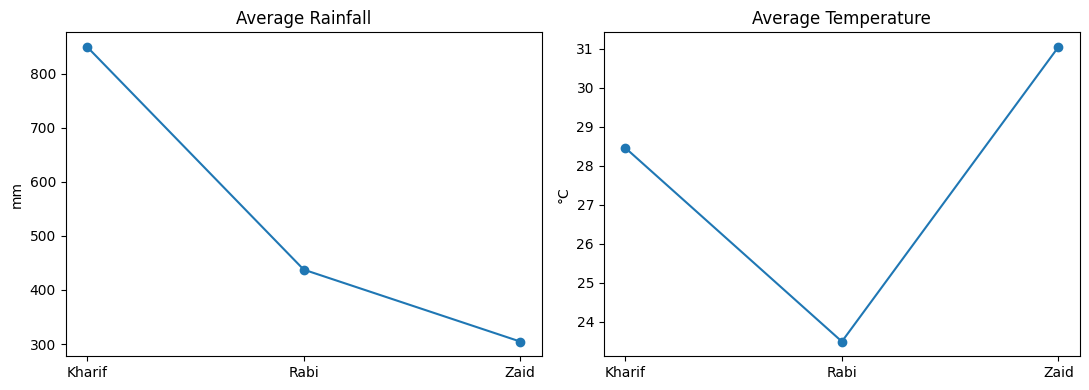

In [8]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(season_order,environment.Rainfall_mm,marker="o")
axes[0].set_title("Average Rainfall"); axes[0].set_ylabel("mm")
axes[1].plot(season_order,environment.Temperature_C,marker="o")
axes[1].set_title("Average Temperature"); axes[1].set_ylabel("°C")
plt.tight_layout(); plt.show()

### Finding
Kharif has the highest average rainfall, while Zaid is the warmest and substantially drier. These environmental contrasts provide context for the observed seasonal differences, but the dataset alone does not establish causality.

## 6. Crop performance

In [9]:
crop_summary=clean.groupby("Crop").agg(
    Farms=("Farm_ID","count"),
    Avg_Yield=("Yield_Tonnes_Ha","mean"),
    Avg_Profit=("Profit_INR","mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean")
).sort_values("Avg_Profit",ascending=False)
display(crop_summary.round(2))

,Farms,Avg_Yield,Avg_Profit,Avg_Water_Efficiency
Crop,,,,
Sugarcane,305,46.64,"817,187.99",30.48
Chilli,412,1.54,"750,878.34",2.95
Cotton,508,1.23,"124,546.92",1.94
Groundnut,424,1.32,"44,858.12",3.15
Pulses,496,0.92,"-4,238.05",2.90
Maize,551,2.71,"-83,978.33",5.60
Rice,690,2.43,"-102,213.50",1.95
Wheat,614,2.11,"-123,398.34",4.63


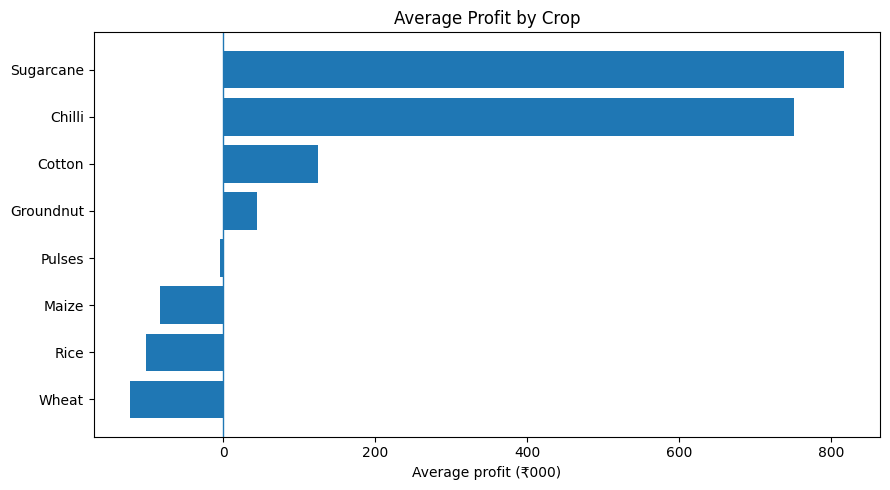

In [10]:
q=crop_summary.sort_values("Avg_Profit")
plt.figure(figsize=(9,5))
plt.barh(q.index,q.Avg_Profit/1000)
plt.axvline(0,linewidth=1)
plt.xlabel("Average profit (₹000)")
plt.title("Average Profit by Crop")
plt.tight_layout(); plt.show()

## 7. Irrigation and water efficiency

In [11]:
irrigation_summary=clean.groupby("Irrigation_Method").agg(
    Farms=("Farm_ID","count"),
    Avg_Yield=("Yield_Tonnes_Ha","mean"),
    Avg_Profit=("Profit_INR","mean"),
    Avg_Water_Used_m3=("Water_Used_m3","mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean")
).sort_values("Avg_Water_Efficiency",ascending=False)
display(irrigation_summary.round(2))

,Farms,Avg_Yield,Avg_Profit,Avg_Water_Used_m3,Avg_Water_Efficiency
Irrigation_Method,,,,,
Rainfed,1041,4.60,"79,050.37","3,549.55",7.56
Drip,915,6.58,"219,626.00","5,918.75",6.27
Sprinkler,734,5.16,"91,121.08","6,208.26",4.67
Flood,1310,4.86,"73,354.02","8,026.47",3.44


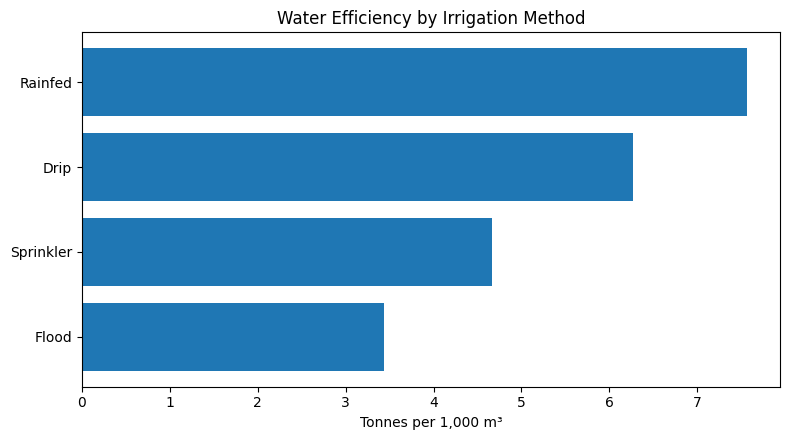

In [12]:
q=irrigation_summary.sort_values("Avg_Water_Efficiency")
plt.figure(figsize=(8,4.5))
plt.barh(q.index,q.Avg_Water_Efficiency)
plt.xlabel("Tonnes per 1,000 m³")
plt.title("Water Efficiency by Irrigation Method")
plt.tight_layout(); plt.show()

### Finding
Water efficiency differs across irrigation methods. Irrigation should therefore be analyzed jointly with crop, season, farm size and region before drawing operational conclusions.

## 8. State / regional benchmarking

In [13]:
state_summary=clean.groupby("State").agg(
    Farms=("Farm_ID","count"),
    Avg_Yield=("Yield_Tonnes_Ha","mean"),
    Avg_Profit=("Profit_INR","mean")
).sort_values("Avg_Profit",ascending=False)
display(state_summary.round(2))

,Farms,Avg_Yield,Avg_Profit
State,,,
Punjab,484,6.12,"136,025.64"
Maharashtra,512,5.02,"135,428.86"
Karnataka,489,5.69,"119,422.34"
Tamil Nadu,485,4.88,"117,744.75"
Gujarat,488,5.66,"117,568.24"
Telangana,516,5.04,"108,829.62"
Madhya Pradesh,497,4.99,"86,840.76"
Andhra Pradesh,529,4.63,"73,453.53"


## 9. Correlation analysis

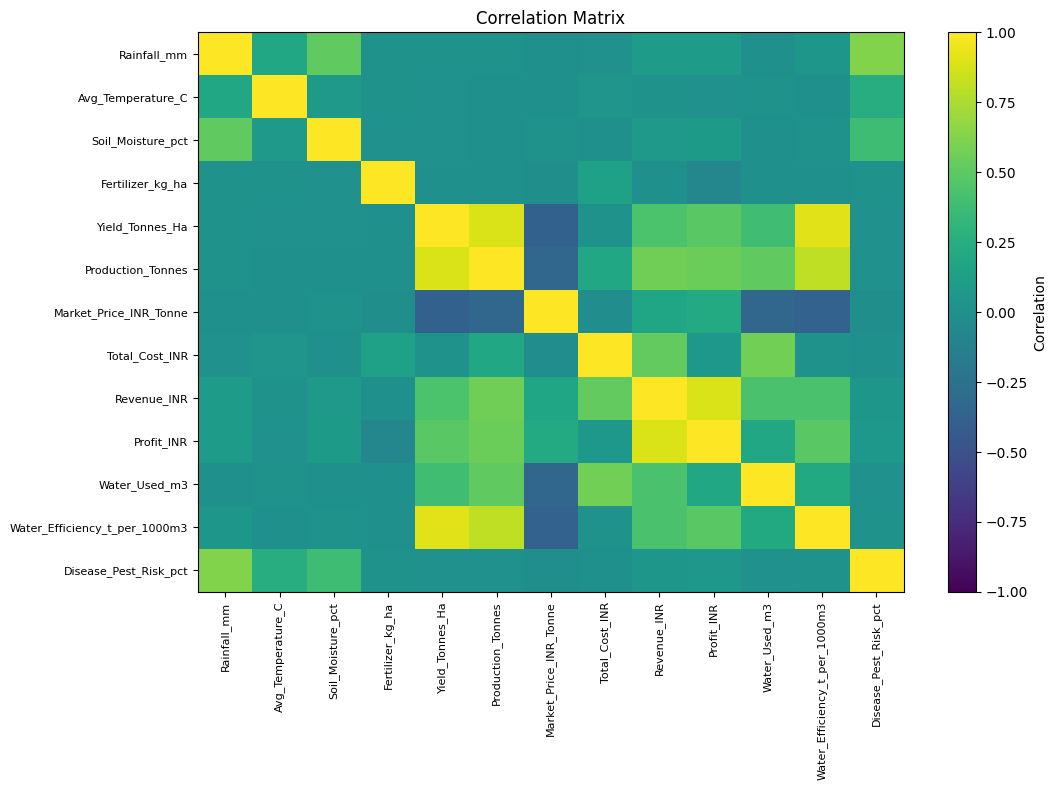

Strongest absolute correlations with Profit:


Revenue_INR                     0.89
Production_Tonnes               0.55
Water_Efficiency_t_per_1000m3   0.49
Yield_Tonnes_Ha                 0.49
Market_Price_INR_Tonne          0.23
Water_Used_m3                   0.19
Rainfall_mm                     0.11
Soil_Moisture_pct               0.09
Name: Profit_INR, dtype: float64

Strongest absolute correlations with Yield:


Water_Efficiency_t_per_1000m3    0.91
Production_Tonnes                0.88
Profit_INR                       0.49
Revenue_INR                      0.43
Water_Used_m3                    0.39
Market_Price_INR_Tonne          -0.38
Rainfall_mm                      0.03
Total_Cost_INR                   0.03
Name: Yield_Tonnes_Ha, dtype: float64

In [14]:
key_numeric=[
    "Rainfall_mm","Avg_Temperature_C","Soil_Moisture_pct","Fertilizer_kg_ha",
    "Yield_Tonnes_Ha","Production_Tonnes","Market_Price_INR_Tonne",
    "Total_Cost_INR","Revenue_INR","Profit_INR","Water_Used_m3",
    "Water_Efficiency_t_per_1000m3","Disease_Pest_Risk_pct"
]
corr=clean[key_numeric].corr()

plt.figure(figsize=(11,8))
plt.imshow(corr,aspect="auto",vmin=-1,vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(key_numeric)),key_numeric,rotation=90,fontsize=8)
plt.yticks(range(len(key_numeric)),key_numeric,fontsize=8)
plt.title("Correlation Matrix")
plt.tight_layout(); plt.show()

print("Strongest absolute correlations with Profit:")
display(corr["Profit_INR"].drop("Profit_INR").sort_values(key=np.abs,ascending=False).head(8))
print("Strongest absolute correlations with Yield:")
display(corr["Yield_Tonnes_Ha"].drop("Yield_Tonnes_Ha").sort_values(key=np.abs,ascending=False).head(8))

### Interpretation
Profit is strongly associated with revenue and production, while yield is strongly associated with water efficiency and production. These are associations, not causal effects, and some relationships are structurally expected from the way the KPIs are defined.

## 10. Statistical test — One-way ANOVA

In [15]:
groups=[clean.loc[clean["Season"]==s,"Yield_Tonnes_Ha"] for s in season_order]
f_stat,p_value=stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.6g}")
print("Result:", "Statistically significant seasonal mean-yield difference at 5%."
      if p_value<0.05 else
      "Insufficient evidence of a seasonal mean-yield difference at 5%.")

F-statistic: 1.5439
p-value: 0.213678
Result: Insufficient evidence of a seasonal mean-yield difference at 5%.


### Interpretation
ANOVA tests whether all three seasonal mean yields are equal. A significant result indicates that at least one seasonal mean differs; it does not identify the exact pairwise differences or prove that season causes the difference.

## 11. Profitability

In [16]:
profitable_share=(clean["Profit_INR"]>0).mean()*100
print(f"Profitable farms: {profitable_share:.2f}%")
print(f"Loss-making farms: {100-profitable_share:.2f}%")

Profitable farms: 50.85%
Loss-making farms: 49.15%
